In [1]:

import anndata as ad
import celltypist
from celltypist import models
import scanpy as sc
import numpy as np

/data_nfs/og86asub/netmap/netmap-evaluation/netmap/.pixi/envs/default/lib/python3.12/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [2]:
np.random.seed(12)

In [3]:
adata = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/netmap/data/blood/SRR/kallisto/mtx_conversions/10x_rep2/')


IsADirectoryError: [Errno 21] Unable to synchronously open file (file read failed: time = Sat Mar 21 23:25:13 2026
, filename = '/data_nfs/og86asub/netmap/netmap-evaluation/netmap/data/blood/SRR/kallisto/mtx_conversions/10x_rep2/', file descriptor = 74, errno = 21, error message = 'Is a directory', buf = 0x7ffc598f4180, total read size = 8, bytes this sub-read = 8, offset = 0)

In [ ]:
adata.var = adata.var.reset_index()
adata.var = adata.var.set_index("gene_symbol")
adata.var.index = adata.var.index.astype(str)
adata.var_names_make_unique()

In [ ]:

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

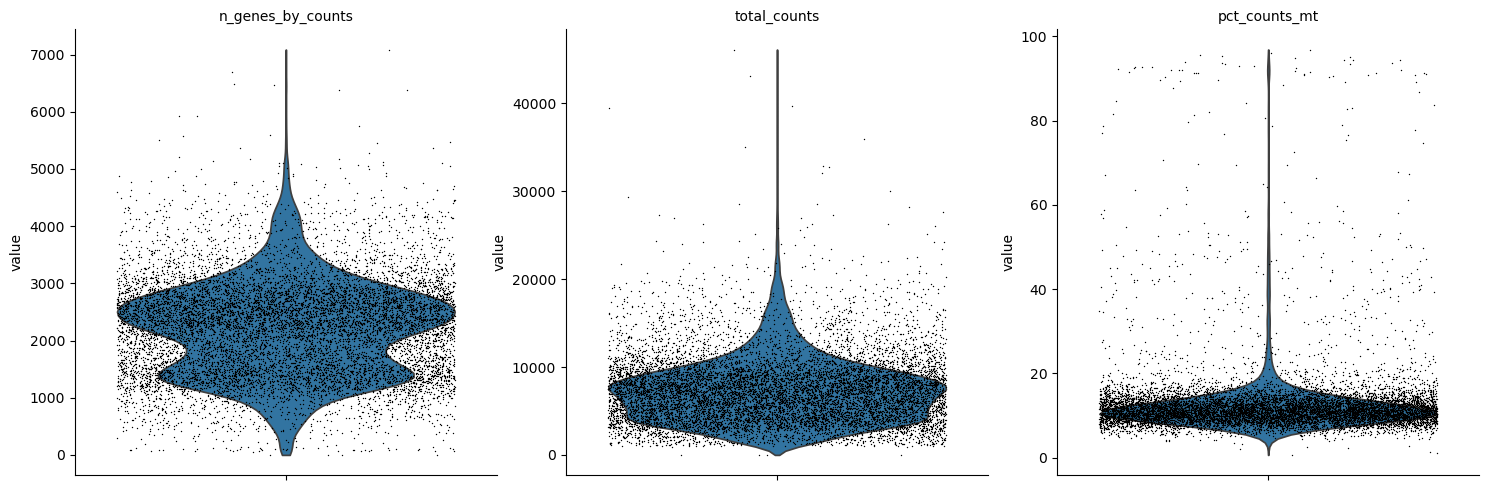

In [ ]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

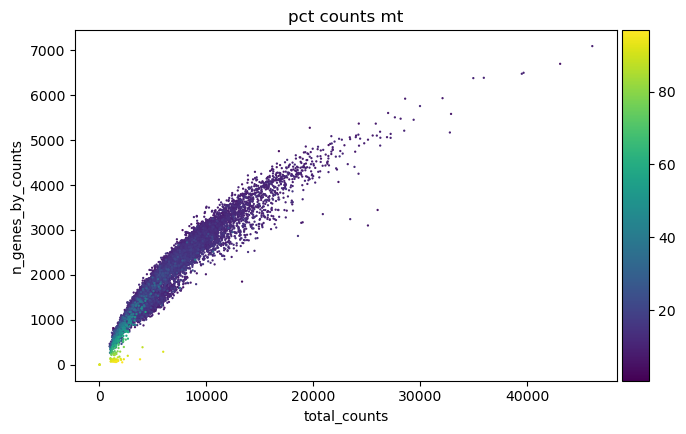

In [ ]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [ ]:
sc.pp.filter_cells(adata, min_genes=500)
sc.pp.filter_genes(adata, min_cells=50)
adata = adata[adata.obs.pct_counts_mt<20]

In [ ]:
sc.pp.scrublet(adata)


In [ ]:
adata = adata[adata.obs.predicted_doublet == False]


In [ ]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [ ]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum = 10000)
adata.layers['count_norm'] = adata.X.copy()
# Logarithmize the data
sc.pp.log1p(adata)

In [ ]:
models.download_models(model = 'Immune_All_Low.pkl', force_update = True)
model = models.Model.load(model = 'Immune_All_High.pkl')
predictions = celltypist.annotate(adata, model = 'Immune_All_High.pkl', majority_voting = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 60
📂 Storing models in /data/og86asub/.celltypist/data/models
💾 Total models to download: 1
💾 Downloading model [1/1]: Immune_All_Low.pkl
🔬 Input data has 10088 cells and 15392 genes
🔗 Matching reference genes in the model
🧬 4484 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [ ]:
adata = predictions.to_adata()
adata.obs.majority_voting.value_counts()

majority_voting
Monocytes                   7140
T cells                     1551
ILC                          612
DC                           333
B cells                      184
pDC                          180
Megakaryocytes/platelets      59
HSC/MPP                       19
Plasma cells                  10
Name: count, dtype: int64

In [ ]:
model = models.Model.load(model = 'Immune_All_Low.pkl')
predictions = celltypist.annotate(adata, model = 'Immune_All_Low.pkl', majority_voting = True)

🔬 Input data has 10088 cells and 15392 genes


🔗 Matching reference genes in the model
🧬 4484 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


In [ ]:
adata.obs['granular']= predictions.predicted_labels['predicted_labels']

In [ ]:
sc.pp.highly_variable_genes(adata, n_top_genes=2500)

In [ ]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.leiden(adata)


In [ ]:
sc.tl.umap(adata)


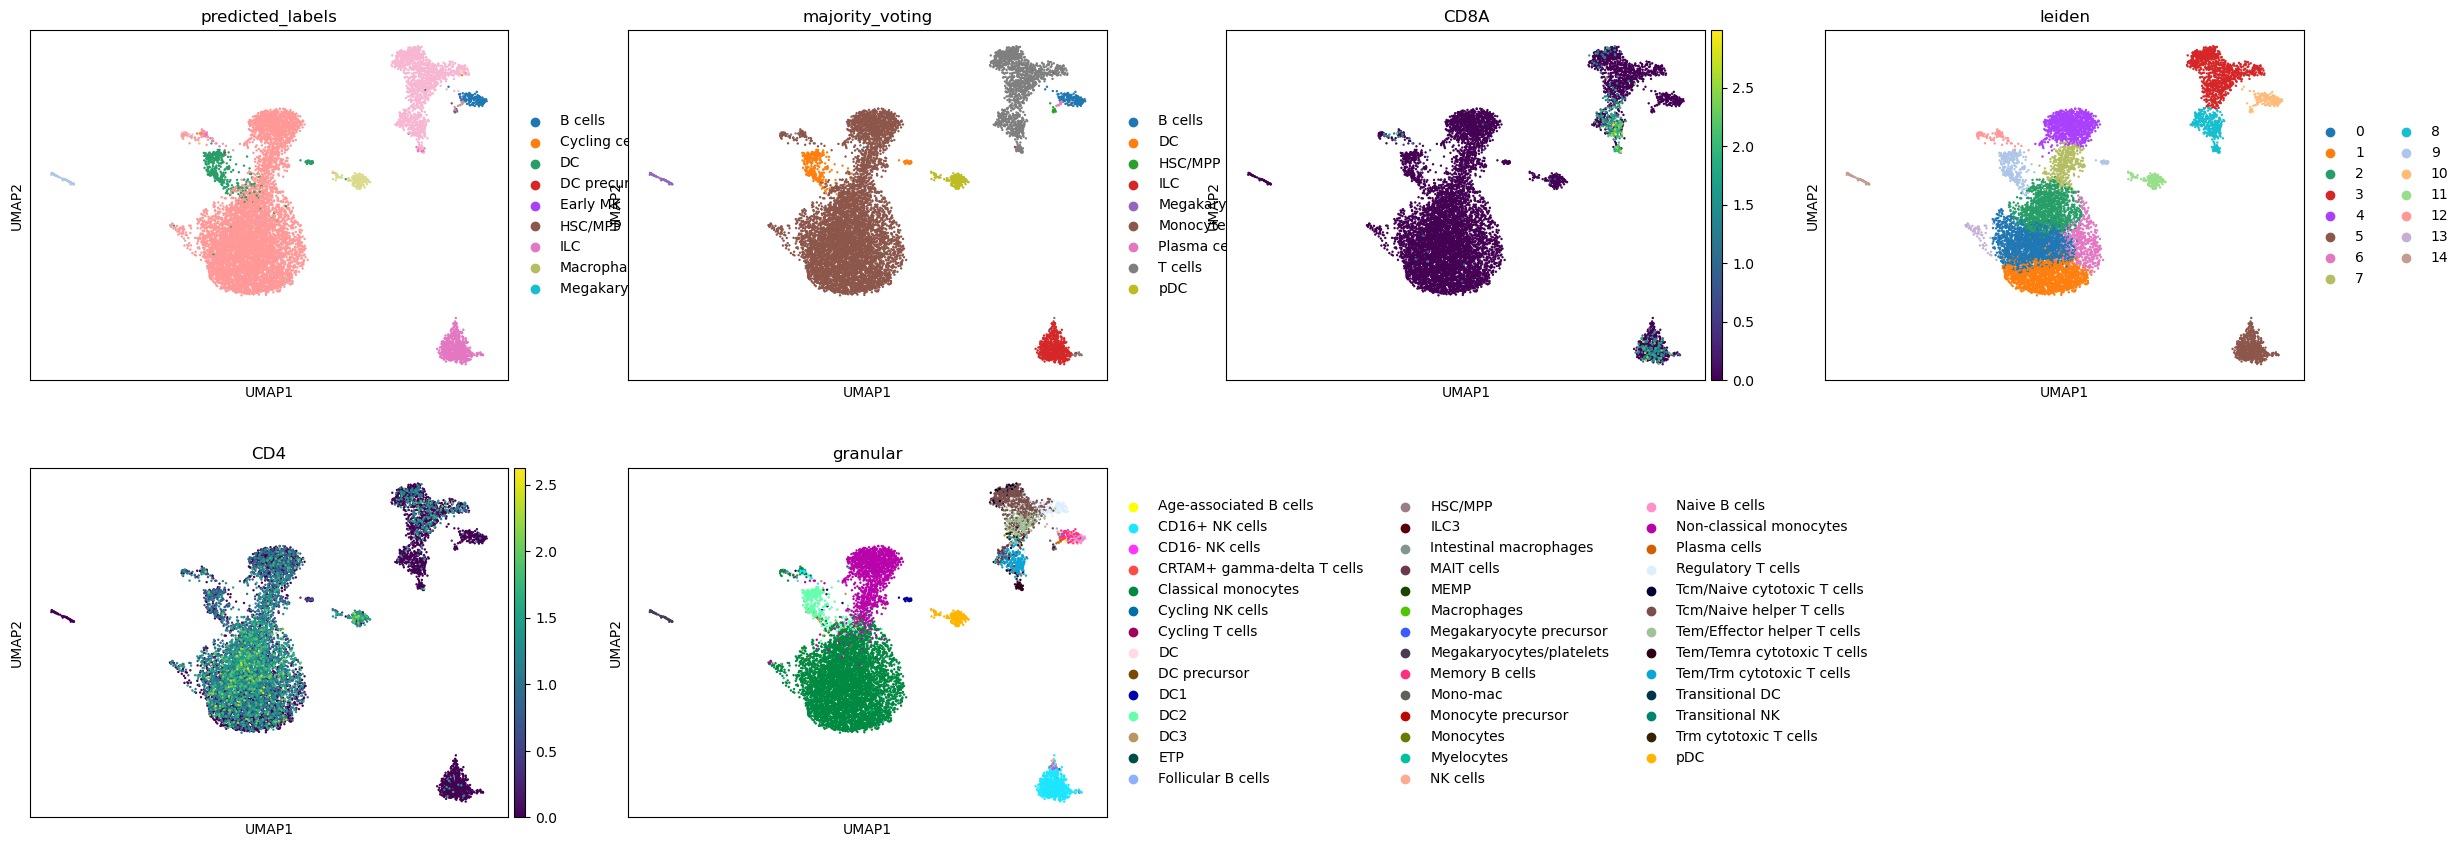

In [ ]:
sc.pl.umap(adata, color = [ 'predicted_labels', 'majority_voting', 'CD8A','leiden', 'CD4', 'granular'])

In [ ]:
celltype_mapping_2 = {
    '0': 'cd4+_tcells',
    '1': 'cd14+_monocytes',
    '2': 'cd14+_monocytes',
    '3': 'cd14+_monocytes',
    '4':  'cd14+_monocytes',
    '5':  'nk_cells',
    '6': 'cd14-_monocytes',
    '7': 'mix',
    '8': 'pDC',
    '9': 'DC',
    '10': 'cd14+_monocytes',
    '11': 'pDC',
    '12': 'cd14+_monocytes',
    '13': 'megakaryocytes'}

In [ ]:
adata.obs['celltype_semi_manual'] = [celltype_mapping_2[c] for c in adata.obs['leiden']]

KeyError: '14'

In [ ]:
adata = adata[:,adata.var.pct_dropout_by_counts<95].copy()

... storing 'celltype_semi_manual' as categorical


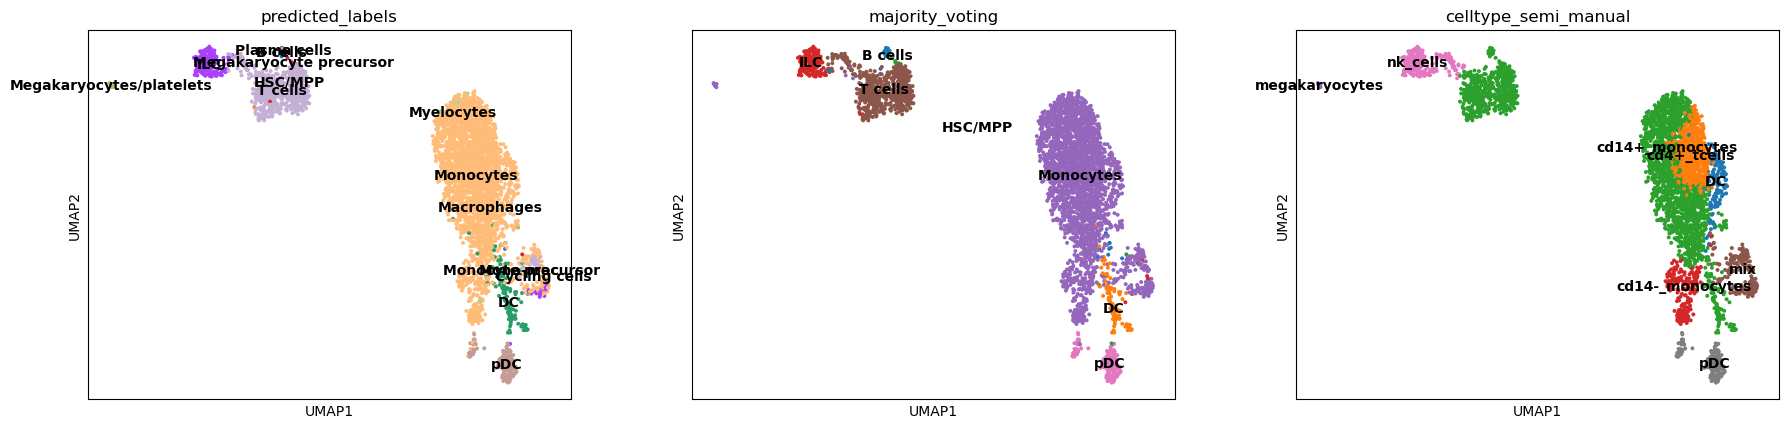

In [ ]:
sc.pl.umap(adata, color = [ 'predicted_labels', 'majority_voting', 'celltype_semi_manual'], legend_loc = 'on data')

In [ ]:
adata.X = np.nan_to_num(adata.X) 
adata.X[adata.X == np.inf] = 0
adata.X[adata.X == -np.inf] = 0



In [ ]:
adata = adata[:, adata.var.highly_variable].copy()

In [ ]:
adata = adata[adata.obs.celltype_semi_manual != 'megakaryocytes'].copy()

In [ ]:
adata.write_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/netmap/data/blood/reprocessed/blood-10x-rep2.h5ad')

In [ ]:
adata.obs.celltype_semi_manual.value_counts()

celltype_semi_manual
cd14+_monocytes    2159
cd4+_tcells         606
nk_cells            251
cd14-_monocytes     210
mix                 187
pDC                 164
DC                  123
Name: count, dtype: int64